<a href="https://colab.research.google.com/github/lucasvazelle/nexialog_challlenge/blob/main/etape4_IsolationForest_PEAG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!ls -lh "/content/drive/MyDrive/nexialog"

ls: /content/drive/MyDrive/nexialog: No such file or directory
lrw------- 1 root root 0 Apr  8 23:29 /content/drive/MyDrive/nexialog -> /content/drive/.shortcut-targets-by-id/1d-uDDNs_H3Y977kY4F9A0elEoUKUxyz6/nexialog


In [4]:
# Chemin
file_path = "/content/drive/MyDrive/nexialog/data_aggrege_PEAG.parquet"

# Lire le fichier Parquet
data_agrege_S3 = pd.read_parquet(file_path)

# Columns
data_agrege_S3.columns

Index(['peag_nro', 'date_hour', 'code_departement', 'olt_model', 'olt_name',
       'boucle', 'dsp', 'pop_dns', 'nb_test_dns', 'avg_dns_time',
       'std_dns_time', 'nb_test_scoring', 'avg_latence_scoring',
       'std_latence_scoring', 'avg_score_scoring', 'std_score_scoring',
       'nb_client_total', 'moment_journee', 'depts_egaux', 'meme_region',
       'missing_avg_dns_time', 'missing_std_dns_time',
       'missing_avg_latence_scoring', 'missing_std_latence_scoring',
       'missing_avg_score_scoring', 'missing_std_score_scoring', 'type_boucle',
       'type_olt_model', 'encodage_heure_sin', 'encodage_heure_cos',
       'encodage_jour_semaine_sin', 'encodage_jour_semaine_cos', 'week_end'],
      dtype='object')

In [5]:
data_agrege_S3.head(5)

,peag_nro,date_hour,code_departement,olt_model,olt_name,boucle,dsp,pop_dns,nb_test_dns,avg_dns_time,...,missing_std_latence_scoring,missing_avg_score_scoring,missing_std_score_scoring,type_boucle,type_olt_model,encodage_heure_sin,encodage_heure_cos,encodage_jour_semaine_sin,encodage_jour_semaine_cos,week_end
0,01_peag_1,2024-12-01 00:00:00,01,old0,01_olt_1,BU966,dsp_1,69_lyon,61,4.888439,...,0,0,0,BU,old,0.000000,1.000000,-0.781831,0.62349,True
1,01_peag_1,2024-12-01 01:00:00,01,old0,01_olt_1,BU966,dsp_1,69_lyon,58,5.293034,...,0,0,0,BU,old,0.258819,0.965926,-0.781831,0.62349,True
2,01_peag_1,2024-12-01 02:00:00,01,old0,01_olt_1,BU966,dsp_1,69_lyon,67,5.103739,...,0,0,0,BU,old,0.500000,0.866025,-0.781831,0.62349,True
3,01_peag_1,2024-12-01 03:00:00,01,old0,01_olt_1,BU966,dsp_1,69_lyon,40,5.342719,...,0,0,0,BU,old,0.707107,0.707107,-0.781831,0.62349,True
4,01_peag_1,2024-12-01 04:00:00,01,old0,01_olt_1,BU966,dsp_1,69_lyon,50,4.997415,...,0,0,0,BU,old,0.866025,0.500000,-0.781831,0.62349,True


In [10]:
import psutil

def check_ram_usage():
    # Affiche l'utilisation actuelle de la RAM en Mo
    mem = psutil.virtual_memory()
    print(f"RAM utilisée : {mem.used // (1024 ** 2)} Mo / {mem.total // (1024 ** 2)} Mo")

check_ram_usage()

RAM utilisée : 3163 Mo / 85480 Mo


# IsolationForest - contamination=0.05 - très sensif

In [7]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

def detect_anomalies_isoforest(df, test_type='dns', contamination=0.05, random_state=42):
    """
    Détecte les anomalies avec Isolation Forest

    Args:
        df: DataFrame avec les données
        test_type: 'dns', 'scoring' ou 'latence'
        contamination: proportion estimée d’anomalies dans les données
        random_state: pour la reproductibilité

    Returns:
        DataFrame avec les prédictions d'anomalies
    """

    # Définir les colonnes spécifiques selon le type de test
    if test_type == 'dns':
        required_cols = ['nb_test_dns', 'avg_dns_time', 'std_dns_time']
        prefix = 'anomaly_dns'
    elif test_type == 'scoring':
        required_cols = ['nb_test_scoring', 'avg_score_scoring', 'std_score_scoring']
        prefix = 'anomaly_scoring'
    elif test_type == 'latence':
        required_cols = ['nb_test_scoring', 'avg_latence_scoring', 'std_latence_scoring']
        prefix = 'anomaly_latence'
    else:
        raise ValueError("test_type doit être 'dns', 'scoring' ou 'latence'")

    # Caractéristiques temporelles à inclure dans le modèle
    time_features = [
        'encodage_heure_sin', 'encodage_heure_cos',
        'encodage_jour_semaine_sin', 'encodage_jour_semaine_cos',
        'week_end'
    ]

    # Filtrer les colonnes qui existent réellement dans le DataFrame
    features = required_cols + time_features
    existing_features = [col for col in features if col in df.columns]

    # Préparer les données en supprimant les lignes avec valeurs manquantes
    df_clean = df[existing_features + ['date_hour']].dropna().copy()

    # Vérifier que les données ne sont pas vides après nettoyage
    if df_clean.empty:
        return None

    # Standardiser les données pour l'algorithme
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df_clean[existing_features])

    # Appliquer le modèle Isolation Forest
    model = IsolationForest(contamination=contamination, random_state=random_state)
    df_clean[prefix] = model.fit_predict(X_scaled)

    # Les valeurs -1 sont des anomalies, 1 sont normales
    return df_clean

In [9]:
# Appliquer le modèle pour chaque type de test
df_anomaly_dns = detect_anomalies_isoforest(data_agrege_S3, test_type='dns')
df_anomaly_score = detect_anomalies_isoforest(data_agrege_S3, test_type='scoring')
df_anomaly_latence = detect_anomalies_isoforest(data_agrege_S3, test_type='latence')

In [19]:
import matplotlib.pyplot as plt

def visualize_isolationforest_anomalies(data, peag_test, test_type='dns'):
    """
    Visualise les anomalies détectées par Isolation Forest pour un PEAG et un type de test.

    Args:
        data: DataFrame complet (ex: data_agrege_S3)
        peag_test: identifiant PEAG à filtrer
        test_type: 'dns', 'scoring', ou 'latence'
    """

    # Filtrer le PEAG
    df_peag = data[data['peag_nro'] == peag_test]

    # Appliquer Isolation Forest
    df_anomalies = detect_anomalies_isoforest(df_peag, test_type=test_type)

    if df_anomalies is not None:
        # Déterminer la colonne d'anomalie et la colonne de valeur à tracer
        if test_type == 'dns':
            anomaly_col = 'anomaly_dns'
            value_col = 'avg_dns_time'
        elif test_type == 'scoring':
            anomaly_col = 'anomaly_scoring'
            value_col = 'avg_score_scoring'
        elif test_type == 'latence':
            anomaly_col = 'anomaly_latence'
            value_col = 'avg_latence_scoring'
        else:
            print("Type de test invalide.")
            return

        # Compter les anomalies
        anomaly_count = sum(df_anomalies[anomaly_col] == -1)
        print(f"Nombre total de points {test_type}: {len(df_anomalies)}")
        print(f"Nombre d'anomalies {test_type}: {anomaly_count} ({anomaly_count/len(df_anomalies)*100:.2f}%)")

        # Tracer le graphique
        plt.figure(figsize=(12, 5))
        plt.plot(df_anomalies['date_hour'], df_anomalies[value_col], label=value_col)
        plt.scatter(
            df_anomalies['date_hour'][df_anomalies[anomaly_col] == -1],
            df_anomalies[value_col][df_anomalies[anomaly_col] == -1],
            color='red', label='Anomalies'
        )
        plt.legend()
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.title(f"{peag_test} – {test_type.capitalize()} – Isolation Forest")
        plt.show()
    else:
        print(f"Aucune donnée {test_type} exploitable pour {peag_test}")

Nombre total de points dns: 1488
Nombre d'anomalies dns: 75 (5.04%)


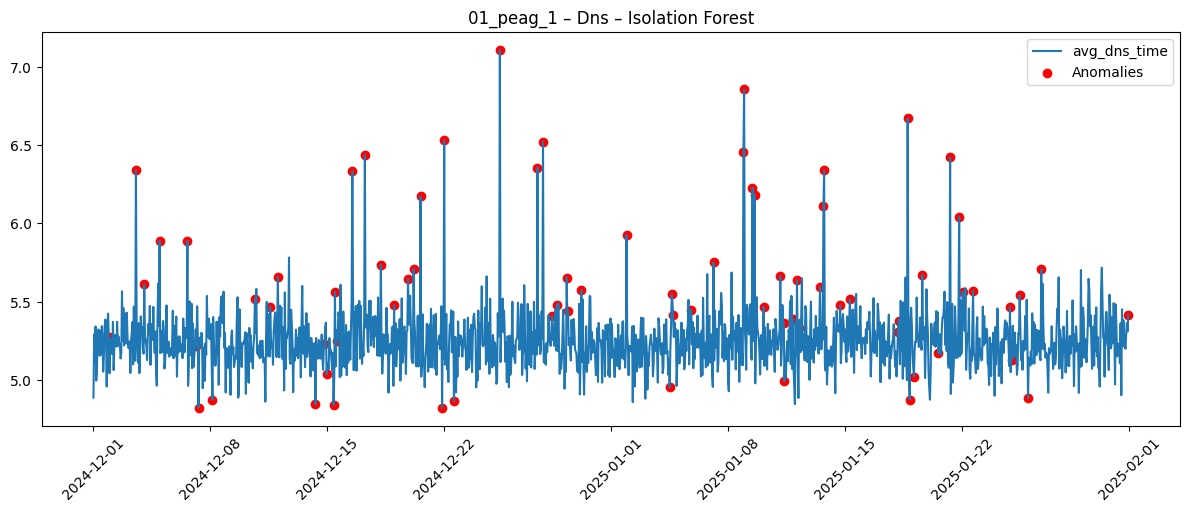

In [14]:
peag_test = "01_peag_1"  # Remplacez par votre PEAG

# Visualiser anomalies pour chaque type de test
visualize_isolationforest_anomalies(data_agrege_S3, peag_test, test_type='dns')

Nombre total de points scoring: 1488
Nombre d'anomalies scoring: 75 (5.04%)


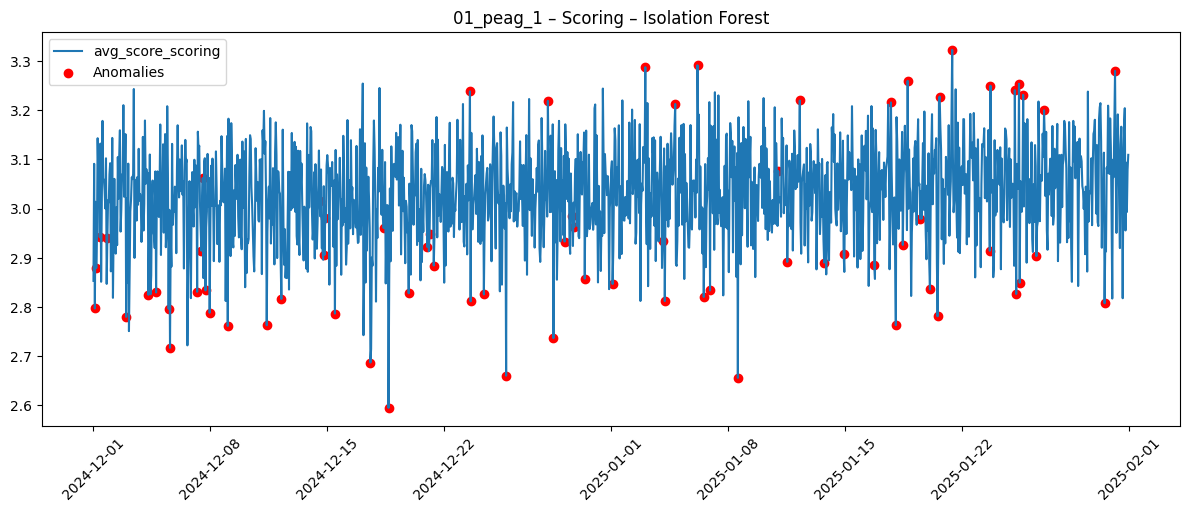

In [15]:
peag_test = "01_peag_1"  # Remplacez par votre PEAG

# Visualiser anomalies pour chaque type de test
visualize_isolationforest_anomalies(data_agrege_S3, peag_test, test_type='scoring')

Nombre total de points latence: 1488
Nombre d'anomalies latence: 75 (5.04%)


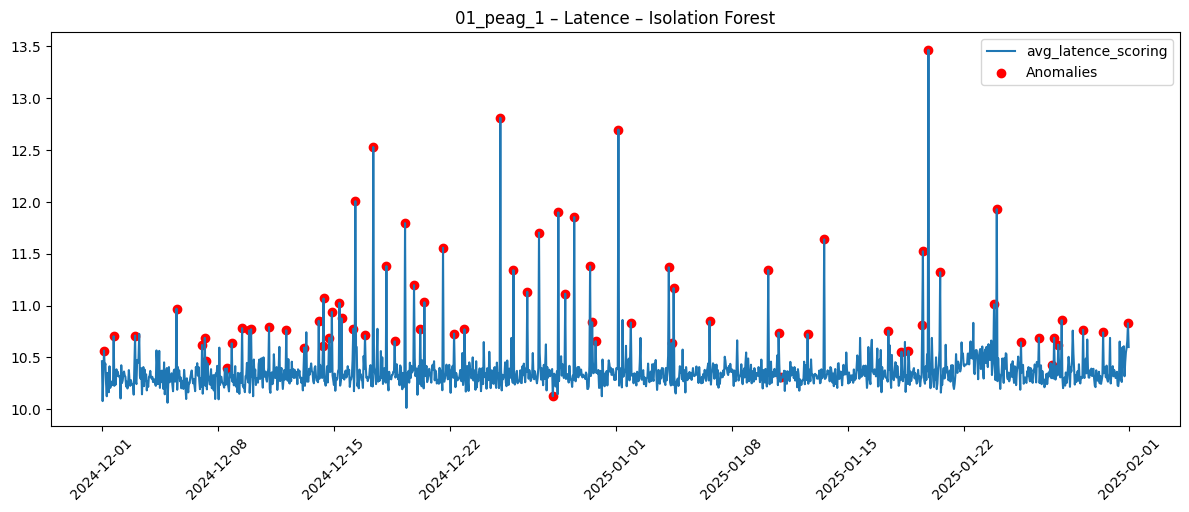

In [16]:
peag_test = "01_peag_1"  # Remplacez par votre PEAG

# Visualiser anomalies pour chaque type de test
visualize_isolationforest_anomalies(data_agrege_S3, peag_test, test_type='latence')

# IsolationForest - contamination=0.03 - moins sensif

In [39]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

def detect_anomalies_isoforest(df, test_type='dns', contamination=0.03, random_state=42, verbose=False):
    """
    Détecte les anomalies avec Isolation Forest

    Args:
        df: DataFrame avec les données
        test_type: 'dns', 'scoring' ou 'latence'
        contamination: proportion estimée d’anomalies dans les données
        random_state: pour la reproductibilité
        verbose: si True, affiche les informations de debug

    Returns:
        DataFrame avec les prédictions d'anomalies
    """

    if verbose:
        print(f"\n=== Détection des anomalies pour test_type = {test_type} ===")

    # Définir les colonnes spécifiques selon le type de test
    if test_type == 'dns':
        required_cols = ['nb_test_dns', 'avg_dns_time', 'std_dns_time']
        prefix = 'anomaly_dns'
    elif test_type == 'scoring':
        required_cols = ['nb_test_scoring', 'avg_score_scoring', 'std_score_scoring']
        prefix = 'anomaly_scoring'
    elif test_type == 'latence':
        required_cols = ['nb_test_scoring', 'avg_latence_scoring', 'std_latence_scoring']
        prefix = 'anomaly_latence'
    else:
        raise ValueError("test_type doit être 'dns', 'scoring' ou 'latence'")

    # Caractéristiques temporelles à inclure dans le modèle
    time_features = [
        'encodage_heure_sin', 'encodage_heure_cos',
        'encodage_jour_semaine_sin', 'encodage_jour_semaine_cos',
        'week_end'
    ]

    # Filtrer les colonnes qui existent réellement dans le DataFrame
    features = required_cols + time_features
    existing_features = [col for col in features if col in df.columns]

    if verbose:
        print(f"→ Features utilisées ({len(existing_features)}): {existing_features}")

    # Préparer les données en supprimant les lignes avec valeurs manquantes
    df_clean = df[existing_features + ['date_hour']].dropna().copy()

    if verbose:
        print(f"→ Données après dropna: {df_clean.shape[0]} lignes")

    # Vérifier que les données ne sont pas vides après nettoyage
    if df_clean.empty:
        if verbose:
            print("⚠️ Données vides après nettoyage, abandon.")
        return None

    if verbose:
        print("→ Statistiques descriptives des colonnes utilisées:")
        print(df_clean[existing_features].describe().transpose().round(2))

    # Standardiser les données
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df_clean[existing_features])

    # Appliquer Isolation Forest
    model = IsolationForest(contamination=contamination, random_state=random_state)
    df_clean[prefix] = model.fit_predict(X_scaled)

    return df_clean

In [32]:
# Appliquer le modèle pour chaque type de test
df_anomaly_dns = detect_anomalies_isoforest(data_agrege_S3, test_type='dns')
df_anomaly_score = detect_anomalies_isoforest(data_agrege_S3, test_type='scoring')
df_anomaly_latence = detect_anomalies_isoforest(data_agrege_S3, test_type='latence')


=== Détection des anomalies pour test_type = dns ===
→ Features utilisées (8): ['nb_test_dns', 'avg_dns_time', 'std_dns_time', 'encodage_heure_sin', 'encodage_heure_cos', 'encodage_jour_semaine_sin', 'encodage_jour_semaine_cos', 'week_end']
→ Données après dropna: 2384134 lignes
→ Statistiques descriptives des colonnes utilisées:
                               count   mean    std   min    25%    50%    75%  \
nb_test_dns                2384134.0  53.52  85.64  5.00  16.00  28.00  58.00   
avg_dns_time               2384134.0   4.31   2.15  0.86   2.79   3.88   5.32   
std_dns_time               2384134.0   0.79   1.87  0.03   0.40   0.55   0.82   
encodage_heure_sin         2384134.0  -0.00   0.71 -1.00  -0.71   0.00   0.71   
encodage_heure_cos         2384134.0  -0.00   0.71 -1.00  -0.71  -0.00   0.71   
encodage_jour_semaine_sin  2384134.0   0.01   0.70 -0.97  -0.78   0.00   0.78   
encodage_jour_semaine_cos  2384134.0   0.00   0.71 -0.90  -0.90  -0.22   0.62   

                  


=== Détection des anomalies pour test_type = dns ===
→ Features utilisées (8): ['nb_test_dns', 'avg_dns_time', 'std_dns_time', 'encodage_heure_sin', 'encodage_heure_cos', 'encodage_jour_semaine_sin', 'encodage_jour_semaine_cos', 'week_end']
→ Données après dropna: 1488 lignes
→ Statistiques descriptives des colonnes utilisées:
                            count   mean    std    min    25%    50%    75%  \
nb_test_dns                1488.0  61.57  11.22  25.00  54.00  61.00  69.00   
avg_dns_time               1488.0   5.26   0.20   4.82   5.14   5.24   5.34   
std_dns_time               1488.0   1.19   0.91   0.74   0.98   1.05   1.14   
encodage_heure_sin         1488.0  -0.00   0.71  -1.00  -0.71   0.00   0.71   
encodage_heure_cos         1488.0  -0.00   0.71  -1.00  -0.71  -0.00   0.71   
encodage_jour_semaine_sin  1488.0   0.02   0.70  -0.97  -0.78   0.00   0.78   
encodage_jour_semaine_cos  1488.0   0.00   0.71  -0.90  -0.90  -0.22   0.62   

                              max  
n

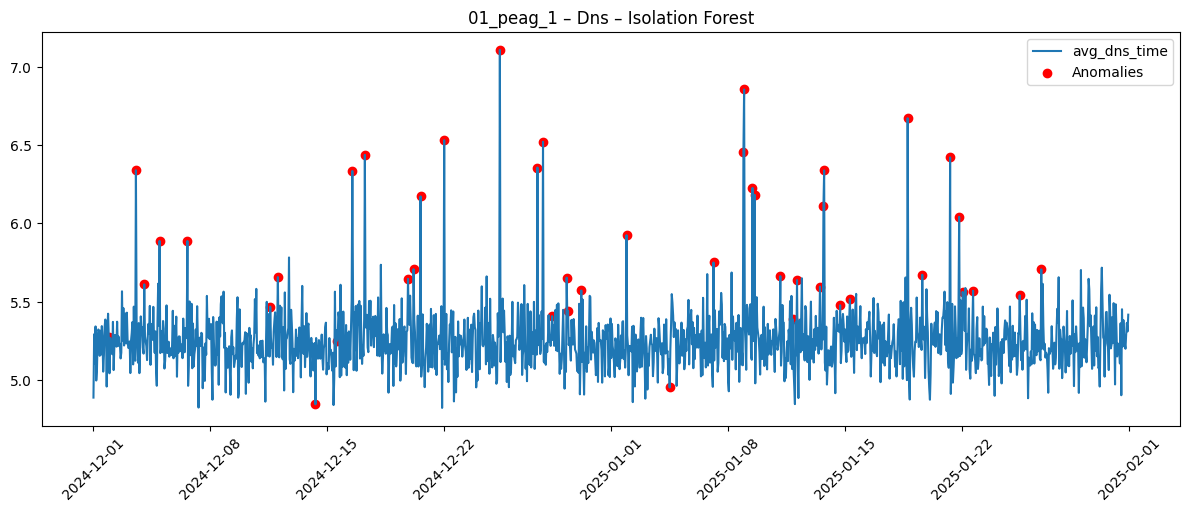

In [34]:
peag_test = "01_peag_1"  # Remplacez par votre PEAG

# Visualiser anomalies pour chaque type de test
visualize_isolationforest_anomalies(data_agrege_S3, peag_test, test_type='dns')


=== Détection des anomalies pour test_type = scoring ===
→ Features utilisées (8): ['nb_test_scoring', 'avg_score_scoring', 'std_score_scoring', 'encodage_heure_sin', 'encodage_heure_cos', 'encodage_jour_semaine_sin', 'encodage_jour_semaine_cos', 'week_end']
→ Données après dropna: 1488 lignes
→ Statistiques descriptives des colonnes utilisées:
                            count   mean   std    min    25%    50%    75%  \
nb_test_scoring            1488.0  30.84  5.68  16.00  27.00  31.00  35.00   
avg_score_scoring          1488.0   3.03  0.10   2.59   2.97   3.03   3.10   
std_score_scoring          1488.0   0.52  0.09   0.34   0.45   0.51   0.59   
encodage_heure_sin         1488.0  -0.00  0.71  -1.00  -0.71   0.00   0.71   
encodage_heure_cos         1488.0  -0.00  0.71  -1.00  -0.71  -0.00   0.71   
encodage_jour_semaine_sin  1488.0   0.02  0.70  -0.97  -0.78   0.00   0.78   
encodage_jour_semaine_cos  1488.0   0.00  0.71  -0.90  -0.90  -0.22   0.62   

                           

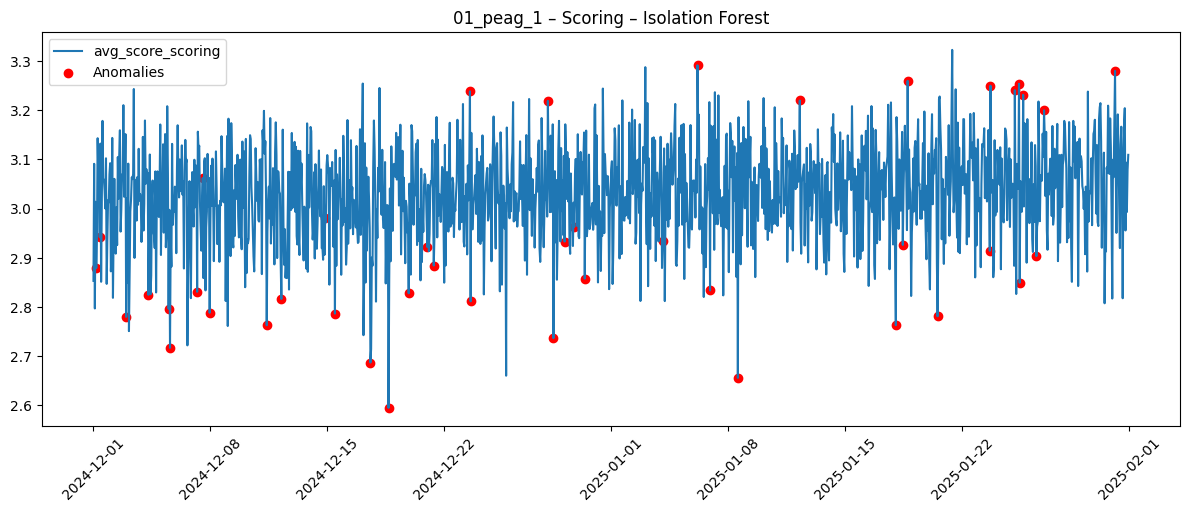

In [35]:
peag_test = "01_peag_1"  # Remplacez par votre PEAG

# Visualiser anomalies pour chaque type de test
visualize_isolationforest_anomalies(data_agrege_S3, peag_test, test_type='scoring')


=== Détection des anomalies pour test_type = latence ===
→ Features utilisées (8): ['nb_test_scoring', 'avg_latence_scoring', 'std_latence_scoring', 'encodage_heure_sin', 'encodage_heure_cos', 'encodage_jour_semaine_sin', 'encodage_jour_semaine_cos', 'week_end']
→ Données après dropna: 1488 lignes
→ Statistiques descriptives des colonnes utilisées:
                            count   mean   std    min    25%    50%    75%  \
nb_test_scoring            1488.0  30.84  5.68  16.00  27.00  31.00  35.00   
avg_latence_scoring        1488.0  10.37  0.22  10.01  10.28  10.33  10.40   
std_latence_scoring        1488.0   0.62  1.06   0.22   0.34   0.39   0.47   
encodage_heure_sin         1488.0  -0.00  0.71  -1.00  -0.71   0.00   0.71   
encodage_heure_cos         1488.0  -0.00  0.71  -1.00  -0.71  -0.00   0.71   
encodage_jour_semaine_sin  1488.0   0.02  0.70  -0.97  -0.78   0.00   0.78   
encodage_jour_semaine_cos  1488.0   0.00  0.71  -0.90  -0.90  -0.22   0.62   

                       

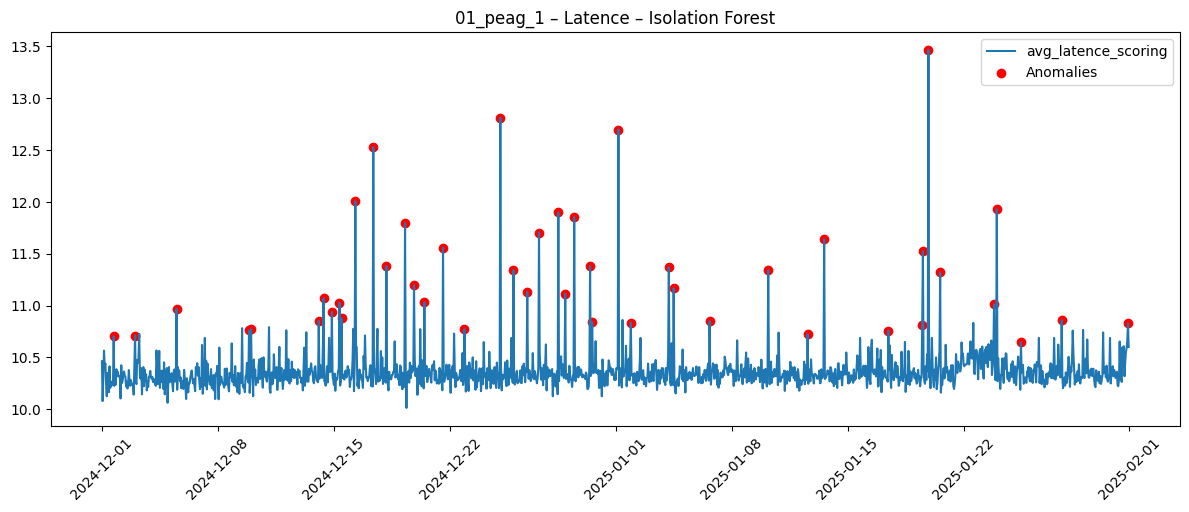

In [36]:
peag_test = "01_peag_1"  # Remplacez par votre PEAG

# Visualiser anomalies pour chaque type de test
visualize_isolationforest_anomalies(data_agrege_S3, peag_test, test_type='latence')

In [40]:
def add_isolationforest_anomaly_columns(df, test_types=['dns', 'scoring', 'latence'], contamination=0.03):
    """
    Applique Isolation Forest à chaque PEAG pour plusieurs types de test,
    et ajoute les colonnes d'anomalies au DataFrame.

    Args:
        df: DataFrame d'entrée (doit contenir 'peag_nro' et 'date_hour')
        test_types: liste des types de test à traiter
        contamination: paramètre de contamination pour Isolation Forest

    Returns:
        DataFrame avec colonnes 'is_anomaly_<type>'
    """

    # Initialiser la copie du dataframe d'origine
    df_result = df.copy()

    # Parcourir chaque PEAG unique
    for peag in df_result['peag_nro'].unique():
        print(f"Traitement de l'OLT: {peag}")
        df_peag = df_result[df_result['peag_nro'] == peag]

        for test_type in test_types:
            print(f"  Type de test: {test_type}")
            df_anomalies = detect_anomalies_isoforest(
                df_peag, test_type=test_type, contamination=contamination, verbose=False
            )

            if df_anomalies is None:
                print("    Aucune donnée exploitable")
                continue

            anomaly_col = f"anomaly_{test_type}"
            flag_col = f"is_anomaly_{test_type}"

            df_anomalies[flag_col] = (df_anomalies[anomaly_col] == -1).astype(int)
            n_anomaly = df_anomalies[flag_col].sum()
            pourcent = n_anomaly / len(df_anomalies) * 100
            print(f"    Anomalies: {n_anomaly} ({pourcent:.2f}%)")

            df_result.loc[
                df_result['date_hour'].isin(df_anomalies['date_hour']) &
                (df_result['peag_nro'] == peag), flag_col
            ] = df_anomalies[flag_col].values

    # Remplacer les NaN par 0
    for test_type in test_types:
        col = f"is_anomaly_{test_type}"
        if col not in df_result.columns:
            df_result[col] = 0
        else:
            df_result[col] = df_result[col].fillna(0).astype(int)

    return df_result

In [41]:
# Définir un sous-ensemble pour tester
peags_test = ["01_peag_1"]
df_test = data_agrege_S3[data_agrege_S3['peag_nro'].isin(peags_test)]

# Appliquer Isolation Forest pour chaque test_type
df_with_anomalies = add_isolationforest_anomaly_columns(df_test, test_types=['dns', 'scoring', 'latence'], contamination=0.01)

# Résumé global
print("\nRésultats globaux:")
print(f"Nombre d'anomalies DNS: {df_with_anomalies['is_anomaly_dns'].sum()}")
print(f"Nombre d'anomalies Scoring: {df_with_anomalies['is_anomaly_scoring'].sum()}")
print(f"Nombre d'anomalies Latence: {df_with_anomalies['is_anomaly_latence'].sum()}")

Traitement de l'OLT: 01_peag_1
  Type de test: dns
    Anomalies: 15 (1.01%)
  Type de test: scoring
    Anomalies: 15 (1.01%)
  Type de test: latence
    Anomalies: 15 (1.01%)

Résultats globaux:
Nombre d'anomalies DNS: 15
Nombre d'anomalies Scoring: 15
Nombre d'anomalies Latence: 15


# Comparaison entre DBScan et IsolationForest

## Pour 01_peag_1

In [42]:
def detect_anomalies_dbscan(df, test_type='dns', eps=3, min_samples=4):
    """
    Détecte les anomalies avec DBSCAN

    Args:
        df: DataFrame avec les données
        test_type: 'dns', 'scoring' ou 'latence'
        eps: Paramètre eps pour DBSCAN
        min_samples: Paramètre min_samples pour DBSCAN

    Returns:
        DataFrame avec les prédictions d'anomalies
    """

    if test_type == 'dns':
        required_cols = ['nb_test_dns', 'avg_dns_time', 'std_dns_time']
        prefix = 'anomaly_dns'
    elif test_type == 'scoring':
        required_cols = ['nb_test_scoring', 'avg_score_scoring', 'std_score_scoring']
        prefix = 'anomaly_scoring'
    elif test_type == 'latence':
        required_cols = ['nb_test_scoring', 'avg_latence_scoring', 'std_latence_scoring']
        prefix = 'anomaly_latence'
    else:
        raise ValueError("test_type doit être 'dns', 'scoring' ou 'latence'")

    # Ajouter les caractéristiques temporelles
    time_features = [
        'encodage_heure_sin', 'encodage_heure_cos',
        'encodage_jour_semaine_sin', 'encodage_jour_semaine_cos',
        'week_end'
    ]

    # Combiner les features
    features = required_cols + time_features

    existing_features = [col for col in features if col in df.columns]

    # Nettoyer les données
    df_clean = df[existing_features + ['date_hour']].dropna().copy()

    if df_clean.empty:
        return None

    # Standardiser les données
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df_clean[existing_features])

    # Appliquer DBSCAN
    model = DBSCAN(eps=eps, min_samples=min_samples)
    df_clean[prefix] = model.fit_predict(X_scaled)

    return df_clean

In [43]:
peag_test = "01_peag_1"
df_peag = data_agrege_S3[data_agrege_S3['peag_nro'] == peag_test]

# Détection DBSCAN
df_anomalies_dbscan = detect_anomalies_dbscan(df_peag, test_type='dns', eps=3, min_samples=4)

# Détection Isolation Forest
df_anomalies_iso = detect_anomalies_isoforest(df_peag, test_type='dns', contamination=0.01, verbose=False)

In [45]:
df_compare = df_anomalies_iso[['date_hour', 'avg_dns_time', 'anomaly_dns']].copy()
df_compare = df_compare.rename(columns={'anomaly_dns': 'iso_anomaly'})

df_compare = df_compare.merge(
    df_anomalies_dbscan[['date_hour', 'avg_dns_time', 'anomaly_dns']].rename(columns={'anomaly_dns': 'dbscan_anomaly'}),
    on='date_hour', suffixes=('', '_dbscan')
)

In [46]:
def classify_case(row):
    if row['iso_anomaly'] == -1 and row['dbscan_anomaly'] == -1:
        return 'IsoF & DBSCAN'
    elif row['iso_anomaly'] == -1:
        return 'IsoF only'
    elif row['dbscan_anomaly'] == -1:
        return 'DBSCAN only'
    else:
        return 'Normal'

df_compare['anomaly_case'] = df_compare.apply(classify_case, axis=1)

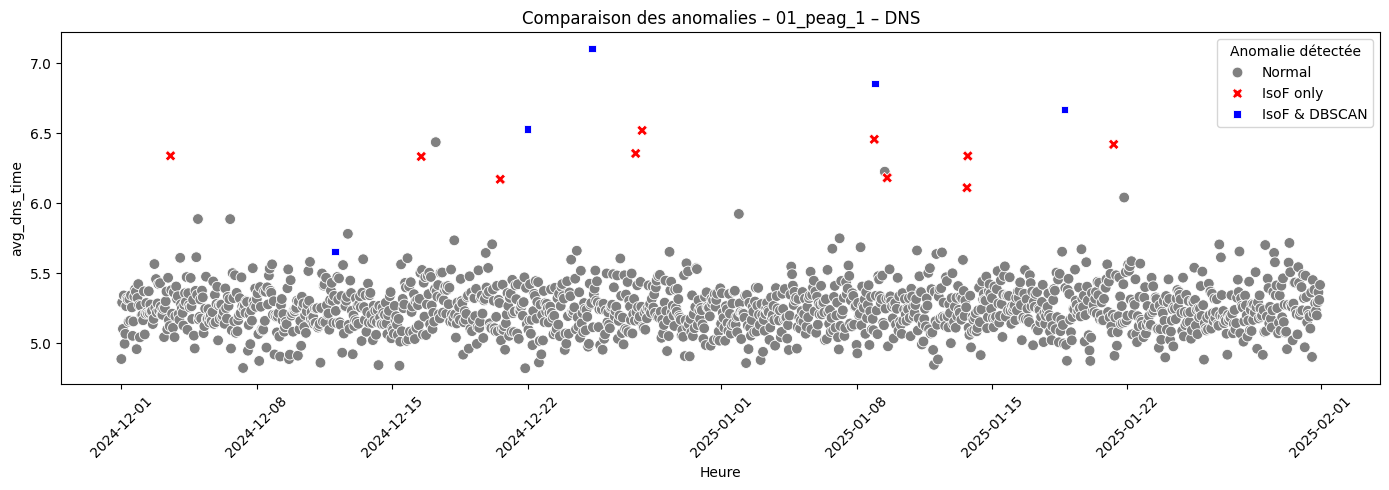

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 5))
sns.scatterplot(
    data=df_compare,
    x='date_hour',
    y='avg_dns_time',
    hue='anomaly_case',
    palette={
        'Normal': 'grey',
        'IsoF only': 'red',
        'DBSCAN only': 'orange',
        'IsoF & DBSCAN': 'blue'
    },
    style='anomaly_case',
    s=60
)

plt.title(f"Comparaison des anomalies – {peag_test} – DNS")
plt.xlabel("Heure")
plt.ylabel("avg_dns_time")
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend(title="Anomalie détectée")
plt.show()

## Pour ["95_peag_5606", "01_peag_29", "01_peag_45"]

In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def compare_anomaly_models_multiple_peags(df, peags_test, test_type='dns', contamination=0.01, eps=3, min_samples=4):
    """
    Compare DBSCAN vs Isolation Forest sur plusieurs PEAGs pour un type de test donné.
    Affiche les scatterplots et résume les détections.

    Args:
        df: DataFrame principal
        peags_test: liste de PEAGs à traiter
        test_type: 'dns', 'scoring', 'latence'
        contamination: paramètre Isolation Forest
        eps, min_samples: paramètres DBSCAN
    """

    for peag in peags_test:
        print(f"\n====== PEAG: {peag} - test_type: {test_type} ======")

        # Sous-ensemble du PEAG
        df_peag = df[df['peag_nro'] == peag]
        print(f"→ Taille brute de df_peag: {df_peag.shape}")

        # Vérifier présence des colonnes clés
        if test_type == 'dns':
            required_cols = ['nb_test_dns', 'avg_dns_time', 'std_dns_time']
        elif test_type == 'scoring':
            required_cols = ['nb_test_scoring', 'avg_score_scoring', 'std_score_scoring']
        elif test_type == 'latence':
            required_cols = ['nb_test_scoring', 'avg_latence_scoring', 'std_latence_scoring']
        else:
            required_cols = []

        missing_cols = [col for col in required_cols if col not in df_peag.columns]
        if missing_cols:
            print(f"❗ Colonnes manquantes dans df_peag: {missing_cols}")

        # DBSCAN
        df_dbscan = detect_anomalies_dbscan(df_peag, test_type=test_type, eps=eps, min_samples=min_samples)

        # Isolation Forest
        df_iso = detect_anomalies_isoforest(df_peag, test_type=test_type, contamination=contamination, verbose=False)

        if df_dbscan is None or df_iso is None:
            print("Données insuffisantes pour ce PEAG.")
            continue

        print(f"→ df_dbscan shape: {df_dbscan.shape}")
        print(f"→ df_iso shape: {df_iso.shape}")

        # Fusion
        df_cmp = df_iso[['date_hour']].copy()
        df_cmp['avg_value'] = df_iso[[col for col in df_iso.columns if col.startswith('avg_')]].iloc[:, 0]
        df_cmp['iso_anomaly'] = df_iso[[col for col in df_iso.columns if col.startswith('anomaly_')]].iloc[:, 0]
        df_cmp['dbscan_anomaly'] = df_dbscan[[col for col in df_dbscan.columns if col.startswith('anomaly_')]].iloc[:, 0]

        print(f"→ df_cmp shape: {df_cmp.shape}")
        print("→ Aperçu de df_cmp:")
        print(df_cmp.head(5))

        # Classification
        def classify(row):
            if row['iso_anomaly'] == -1 and row['dbscan_anomaly'] == -1:
                return 'IsoF & DBSCAN'
            elif row['iso_anomaly'] == -1:
                return 'IsoF only'
            elif row['dbscan_anomaly'] == -1:
                return 'DBSCAN only'
            else:
                return 'Normal'
        df_cmp['anomaly_case'] = df_cmp.apply(classify, axis=1)

        # Compter
        counts = df_cmp['anomaly_case'].value_counts()
        print("Résumé des cas détectés:")
        print(counts.to_string())

        # Visualisation
        plt.figure(figsize=(14, 5))
        sns.scatterplot(
            data=df_cmp,
            x='date_hour',
            y='avg_value',
            hue='anomaly_case',
            palette={
                'Normal': 'grey',
                'IsoF only': 'red',
                'DBSCAN only': 'orange',
                'IsoF & DBSCAN': 'blue'
            },
            style='anomaly_case',
            s=60
        )
        plt.title(f"{peag} – {test_type.upper()} – DBSCAN vs Isolation Forest")
        plt.xlabel("Heure")
        plt.ylabel("Valeur moyenne")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.legend(title="Anomalie détectée")
        plt.show()


====== PEAG: 95_peag_5606 - test_type: dns ======
→ Taille brute de df_peag: (0, 33)
Données insuffisantes pour ce PEAG.

====== PEAG: 01_peag_29 - test_type: dns ======
→ Taille brute de df_peag: (565, 33)
→ df_dbscan shape: (565, 10)
→ df_iso shape: (565, 10)
→ df_cmp shape: (565, 4)
→ Aperçu de df_cmp:
                date_hour  avg_value  iso_anomaly  dbscan_anomaly
10626 2024-12-01 06:00:00   2.987830            1               0
10627 2024-12-01 07:00:00   2.806406            1               0
10628 2024-12-01 08:00:00   2.970333            1               0
10629 2024-12-01 09:00:00   3.113114            1               0
10630 2024-12-01 10:00:00   3.158125            1               0
Résumé des cas détectés:
anomaly_case
Normal           558
IsoF & DBSCAN      6
DBSCAN only        1


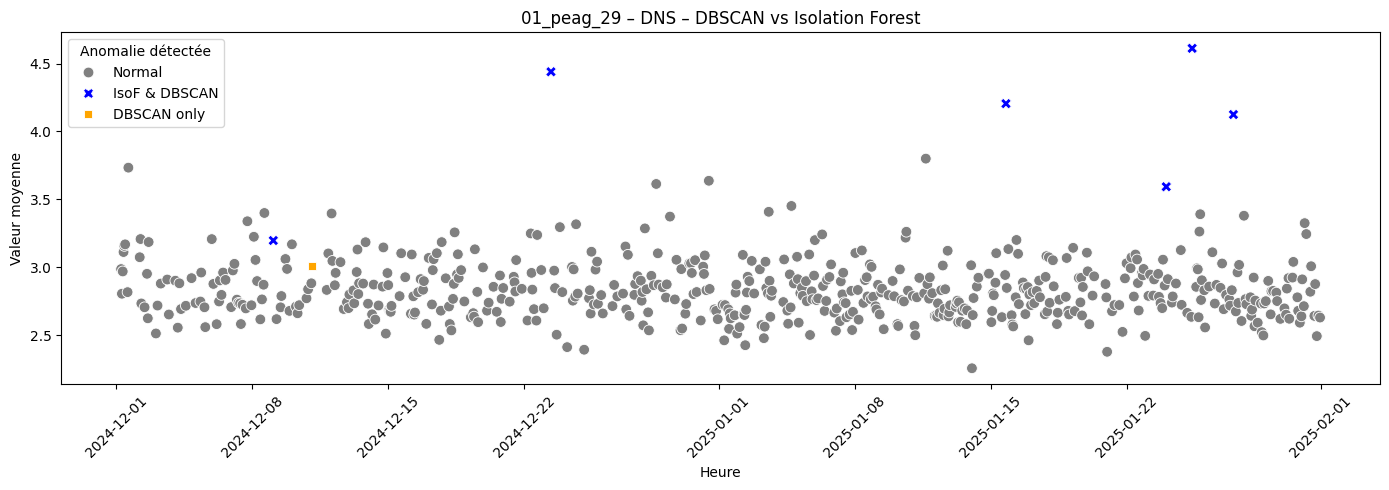


====== PEAG: 01_peag_45 - test_type: dns ======
→ Taille brute de df_peag: (0, 33)
Données insuffisantes pour ce PEAG.


In [52]:
peags_test = ["95_peag_5606", "01_peag_29", "01_peag_45"]
compare_anomaly_models_multiple_peags(data_agrege_S3, peags_test, test_type='dns', contamination=0.01, eps=3, min_samples=4)